# Procrustes Alignment Explorer

Visualises the joint sample-correspondence + orthogonal Procrustes alignment
for a single teacher–student pair from the heatmap.

Key idea: rather than averaging over 512 samples, we show the **individual matched
pairs** that the Hungarian algorithm selected — both in trajectory space (PCA
projection) and as a cost-matrix heatmap.

In [ ]:
import numpy as np  # needed for MATCH_WEIGHTS below

# ── Configuration ─────────────────────────────────────────────────────────────
# Unablated teacher vs unablated student.
# Set TEACHER_DIRECTION_IDX = 0..13 to switch to an ablated teacher.

TEACHER_RUN            = 'index_cued_first_diffusion_0.3_swap_7'
TEACHER_DIRECTION_IDX  = 2  # None = unablated teacher

STUDENT_RUN            = 'index_cued_first_diffusion_0.3_swap_recovery_ablation_1_0'

N_SAMPLES   = 512        # must match cached trajectories
N_TRIALS    = 288        # must match cached trajectories
DEVICE      = 'cuda'

# ── Which trial to inspect in the per-trial plots ─────────────────────────────
# Trial 6: cue=1, color1=0°, color2=180° (maximally distinct items)
TRIAL_IDX   = 6

# ── How many sample trajectories to DRAW in cloud/PCA plots ───────────────────
N_SAMPLES_PLOT = 512
N_PAIRS_SHOW   = 512
N_HIGHLIGHT  = 5

# ── Trajectory mode ──────────────────────────────────────────────────────────
# 'prep'      : preparatory period only   (T=26)
# 'full'      : prep + denoising steps    (T=66)
# 'diffusion' : denoising steps only      (T=40)
TRAJ_MODE = 'full'

# ── Temporal weighting for Hungarian + Procrustes ─────────────────────────────
# Controls which timesteps matter when matching samples and fitting the rotation.
#   'uniform'  — equal weight on every timestep  [matches run_heatmap_15dirs script]
#   'final'    — all weight on the last timestep only
#   'last_k'   — equal weight on the last WEIGHT_LAST_K timesteps, zero elsewhere
#   'override' — anchor timesteps: t=0, prep/diff boundary, t=T-1 (set in cell-4)
#
# NOTE: 'last_k' restricted to diffusion timesteps causes near-zero cross-covariance
# (noisy/uncorrelated states) → degenerate scale c ≈ 0.  Use 'uniform' for scaled
# Procrustes consistent with the main heatmap analysis (MATCH_WEIGHTS=None).
WEIGHT_MODE = 'uniform'
WEIGHT_LAST_K = 6          # used only when WEIGHT_MODE == 'last_k'
MATCH_WEIGHTS_OVERRIDE = None   # unused — 'override' weights are built in cell-4

# ── Paths ─────────────────────────────────────────────────────────────────────
import sys, os
from pathlib import Path
REPO_ROOT  = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
CACHE_DIR  = REPO_ROOT / 'ddpm/analysis/new_analysis/results/procrustes_heatmap/traj_cache'
sys.path.insert(0, str(REPO_ROOT))

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

from ddpm.analysis.new_analysis.procrustes_heatmap import (
    align_trajectories, project_to_nullspace
)

rng = np.random.default_rng(42)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load trajectories and run alignment

In [82]:
def _cache_path(label, direction_idx, n_samples, full=False):
    suffix = f'abl{direction_idx:02d}' if direction_idx is not None else 'unablated'
    full_part = '_full' if full else ''
    return CACHE_DIR / f'{label}_{suffix}{full_part}_S{n_samples}.npy'

needs_full = TRAJ_MODE in ('full', 'diffusion')
t_path = _cache_path(TEACHER_RUN, TEACHER_DIRECTION_IDX, N_SAMPLES, full=needs_full)
s_path = _cache_path(STUDENT_RUN, None, N_SAMPLES, full=needs_full)
print(f'TRAJ_MODE={TRAJ_MODE!r}')
print(f'Teacher: {t_path.name}  exists={t_path.exists()}')
print(f'Student: {s_path.name}  exists={s_path.exists()}')

T16_raw = np.load(t_path)
S16_raw = np.load(s_path)

T_PREP_STEPS = 26   # prep/diffusion boundary in the full-path cache
if TRAJ_MODE == 'diffusion':
    T16 = T16_raw[:, :, T_PREP_STEPS:, :]
    S16 = S16_raw[:, :, T_PREP_STEPS:, :]
else:
    T16, S16 = T16_raw, S16_raw

T_ALIGN = T16.shape[2]

if WEIGHT_MODE == 'override':
    # Weight at: t=0 (start), t=T_PREP_STEPS-1 (end of prep),
    #            t=T_PREP_STEPS (start of diffusion), t=T_ALIGN-1 (final)
    MATCH_WEIGHTS = np.zeros(T_ALIGN, dtype=np.float32)
    MATCH_WEIGHTS[0] = 1.0
    if TRAJ_MODE == 'full':
        MATCH_WEIGHTS[T_PREP_STEPS - 1] = 1.0
        MATCH_WEIGHTS[T_PREP_STEPS]     = 1.0
    MATCH_WEIGHTS[-1] = 1.0
elif WEIGHT_MODE == 'final':
    MATCH_WEIGHTS = np.zeros(T_ALIGN, dtype=np.float32); MATCH_WEIGHTS[-1] = 1.0
elif WEIGHT_MODE == 'last_k':
    MATCH_WEIGHTS = np.zeros(T_ALIGN, dtype=np.float32); MATCH_WEIGHTS[-WEIGHT_LAST_K:] = 1.0
else:  # 'uniform'
    MATCH_WEIGHTS = np.ones(T_ALIGN, dtype=np.float32)

print(f'T16={T16.shape}   S16={S16.shape}')
print(f'T_ALIGN={T_ALIGN}   WEIGHT_MODE={WEIGHT_MODE!r}   nonzero timesteps={int((MATCH_WEIGHTS > 0).sum())}')
if WEIGHT_MODE == 'override':
    print(f'  weighted at: {np.where(MATCH_WEIGHTS > 0)[0].tolist()}')

TRAJ_MODE='full'
Teacher: index_cued_first_diffusion_0.3_swap_7_abl02_full_S512.npy  exists=True
Student: index_cued_first_diffusion_0.3_swap_recovery_ablation_1_0_unablated_full_S512.npy  exists=True
T16=(288, 512, 66, 16)   S16=(288, 512, 66, 16)
T_ALIGN=66   WEIGHT_MODE='last_k'   nonzero timesteps=6


In [83]:
# Load nullspace and project 16-D trajectories into 14-D behavioural nullspace.
import json as _json
results_root = REPO_ROOT / 'results_link_sampler'
with open(results_root / TEACHER_RUN / 'nullspace_and_projection.json') as _f:
    _ns = _json.load(_f)
_vecs = _ns['nullspace_vectors']['vectors']
nullspace = np.stack([np.array(_vecs[k]) for k in sorted(_vecs)]).astype(np.float32)  # (14,16)
print(f'Nullspace: {nullspace.shape}  (rows are orthonormal nullspace vectors)')

X = project_to_nullspace(T16, nullspace).astype(np.float32)   # (N, S, T, 14)
Y = project_to_nullspace(S16, nullspace).astype(np.float32)   # (N, S, T, 14)
print(f'X={X.shape}  Y={Y.shape}')

Nullspace: (14, 16)  (rows are orthonormal nullspace vectors)
X=(288, 512, 66, 14)  Y=(288, 512, 66, 14)


In [84]:
# Run alignment (GPU; ~5-10 s from projected arrays)
result = align_trajectories(
    X, Y,
    allow_scaling=True,
    n_restarts=3,
    max_iter=50,
    tol=1e-5,
    n_jobs=-1,
    seed=42,
    device=DEVICE,
    match_weights=MATCH_WEIGHTS,
)

print(f'Residual (aligned):  {result.residual:.4f}')
print(f'Residual (identity): {result.identity_residual:.4f}')
print(f'Scale c:             {result.c:.4f}')
print(f'Objective trace:     {[f"{v:.4f}" for v in result.objective_trace]}')
print(f'Restart residuals:   {[f"{v:.4f}" for v in result.restart_residuals]}')

Residual (aligned):  0.0041
Residual (identity): 0.9997
Scale c:             0.0003
Objective trace:     ['0.0041', '0.0041', '0.0041']
Restart residuals:   ['0.0041', '0.0041', '0.0041']


In [ ]:
# Unpack alignment results
R       = result.R          # (M, M) orthogonal rotation
c       = result.c          # positive scale  (objective: ||c·X@R − Y||, so c ≈ ||Y||/||X||)
matches = result.matches    # (N, S) int — matches[n, k] = student sample for teacher k

N, S, T, M = X.shape

# Apply the same per-trajectory centering that align_trajectories did internally.
# Each trajectory is shifted so its temporal mean is zero — this is what makes the
# rotation well-defined (Procrustes cannot absorb translations, only rotations).
X_c = X - X.mean(axis=2, keepdims=True)   # (N, S, T, M)
Y_c = Y - Y.mean(axis=2, keepdims=True)

# Build arrays for the selected trial in teacher's natural (centred) frame.
n = TRIAL_IDX
X_n    = X_c[n]                              # (S, T, M) centred teacher samples
Y_n    = Y_c[n]                              # (S, T, M) centred student samples
Y_match_n      = Y_n[matches[n]]             # (S, T, M) student reordered by Hungarian
# Convention: c·X@R ≈ Y  →  Y in teacher frame = Y@R.T / c
Y_aligned_n    = (Y_match_n @ R.T) / c       # (S, T, M) matched student → teacher frame
Y_natural_aligned = (Y_n @ R.T) / c          # (S, T, M) all student samples → teacher frame

# Xr_n kept only for the cost-matrix cell (uses original Procrustes cost definition)
Xr_n = c * (X_n @ R)

teacher_rms = np.sqrt((X_n**2).mean())
student_rms = np.sqrt((Y_n**2).mean())
print(f'Trial {n}: X_n={X_n.shape}  Y_aligned_n={Y_aligned_n.shape}')
print(f'Teacher centred RMS: {teacher_rms:.4f}')
print(f'Student centred RMS: {student_rms:.4f}')
print(f'Raw amplitude ratio (teacher/student): {teacher_rms/student_rms:.4f}')
print(f'Scale c={c:.4f}  (c ≈ student/teacher amplitude; 1/c = {1/c:.4f})')
print(f'  Aligned student RMS (in teacher frame): {np.sqrt((Y_aligned_n**2).mean()):.4f}')

Prep  t=0-25:  8.8%  Diff  t=26-65: 91.2%


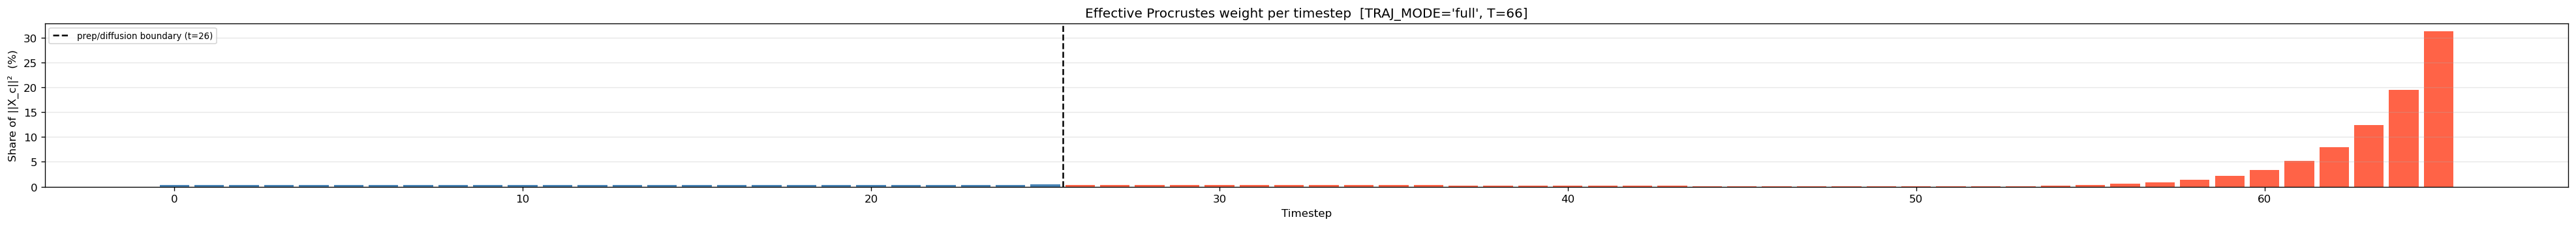

Peak t=65 (31.3%)   Final t=65 (31.26%)


In [86]:
# Per-timestep share of ||X_c||^2 — effective Procrustes weight per timestep.
X_c_16 = T16 - T16.mean(axis=2, keepdims=True)
per_t  = (X_c_16 ** 2).mean(axis=(0, 1, 3))
frac   = per_t / per_t.sum() * 100

fig, ax = plt.subplots(figsize=(max(8, T // 2), 3))
if TRAJ_MODE == 'full':
    bar_colors = ['steelblue' if t < T_PREP_STEPS else 'tomato' for t in range(T)]
elif TRAJ_MODE == 'prep':
    bar_colors = 'steelblue'
else:
    bar_colors = 'tomato'
ax.bar(np.arange(T), frac, color=bar_colors, edgecolor='none', width=0.85)
if TRAJ_MODE == 'full':
    ax.axvline(T_PREP_STEPS - 0.5, color='k', lw=1.5, ls='--',
               label=f'prep/diffusion boundary (t={T_PREP_STEPS})')
    ax.legend(fontsize=8)
    print(f'Prep  t=0-{T_PREP_STEPS-1}:  {frac[:T_PREP_STEPS].sum():.1f}%  '
          f'Diff  t={T_PREP_STEPS}-{T-1}: {frac[T_PREP_STEPS:].sum():.1f}%')
ax.set_xlabel('Timestep')
ax.set_ylabel('Share of ||X_c||²  (%)')
ax.set_title(f'Effective Procrustes weight per timestep  [TRAJ_MODE={TRAJ_MODE!r}, T={T}]')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Peak t={int(np.argmax(frac))} ({frac.max():.1f}%)   Final t={T-1} ({frac[-1]:.2f}%)')


## 2. Convergence trace

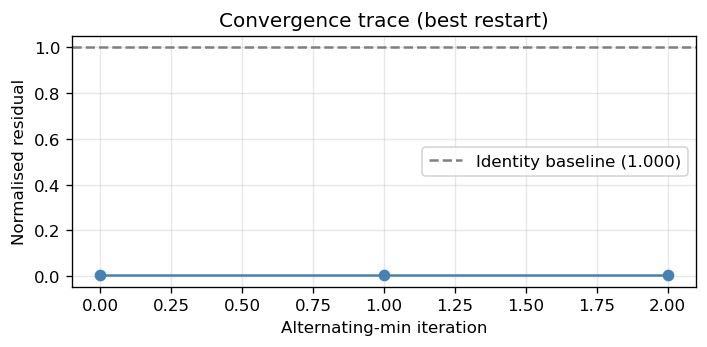

In [87]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(result.objective_trace, '-o', color='steelblue')
ax.axhline(result.identity_residual, color='grey', ls='--', label=f'Identity baseline ({result.identity_residual:.3f})')
ax.set_xlabel('Alternating-min iteration')
ax.set_ylabel('Normalised residual')
ax.set_title('Convergence trace (best restart)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. PCA setup for the selected trial

Fit a joint spatial PCA on teacher (natural frame) + student (rotated into teacher frame).
Both sets are now in the teacher's coordinate system so axes are directly interpretable.

In [88]:
# Fit spatial PCA on teacher (natural) + student (rotated to teacher frame).
# Both are in the teacher's 16-D coordinate system (full hidden state).
spatial_data = np.concatenate([
    X_n.reshape(-1, M),
    Y_aligned_n.reshape(-1, M),
], axis=0)   # (2*S*T, M)
spca = PCA(n_components=3)
spca.fit(spatial_data)
print(f'Spatial PCA explained variance (3 PCs): {spca.explained_variance_ratio_.cumsum()[-1]*100:.1f}%')
print(f'Per-PC explained: {[f"{v*100:.1f}%" for v in spca.explained_variance_ratio_]}')

def project_spatial(traj):
    """(S, T, M) → (S, T, 3): spatial PCA applied at each timestep."""
    s = traj.shape[0]
    flat = traj.reshape(s * T, M)
    return spca.transform(flat).reshape(s, T, 3)

Spatial PCA explained variance (3 PCs): 99.2%
Per-PC explained: ['82.7%', '15.8%', '0.7%']


## 4. Cost matrix and Hungarian assignment (trial `TRIAL_IDX`)

The full 512×512 cost matrix is too dense to read, so we show a 64×64 submatrix
(first 64 teacher vs first 64 student samples) with the assignment overlaid.

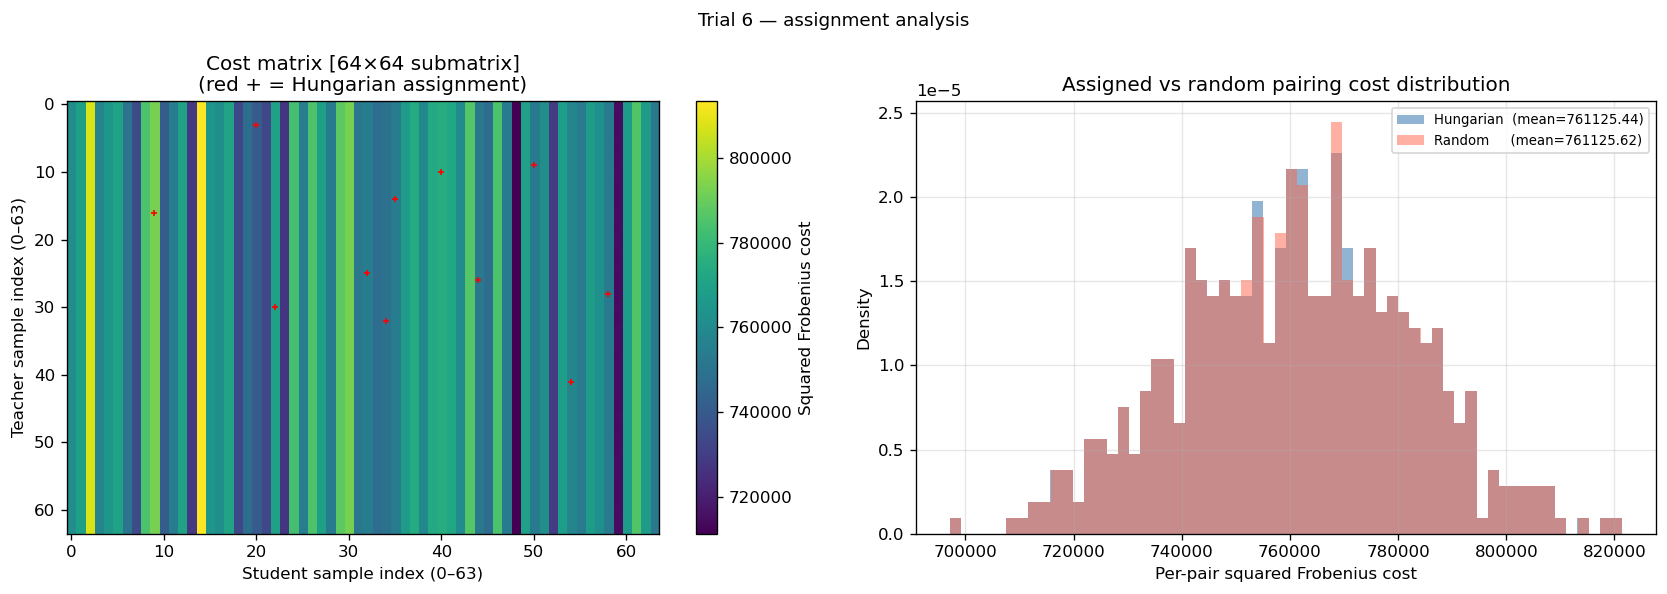

In [89]:
from ddpm.analysis.new_analysis.procrustes_heatmap import _compute_cost_matrices_gpu
import torch

SHOW = 64   # submatrix size

X_t = torch.as_tensor(X[[n]], dtype=torch.float32, device=DEVICE)   # (1, S, T, M)
Y_t = torch.as_tensor(Y[[n]], dtype=torch.float32, device=DEVICE)
R_t = torch.as_tensor(R, dtype=torch.float32, device=DEVICE)
cost_full = _compute_cost_matrices_gpu(X_t, Y_t, R_t, c)[0].cpu().numpy()  # (S, S)

cost_sub = cost_full[:SHOW, :SHOW]
assign_sub = matches[n, :SHOW]   # student index matched to each of first SHOW teachers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cost submatrix
ax = axes[0]
im = ax.imshow(cost_sub, aspect='auto', cmap='viridis', origin='upper')
plt.colorbar(im, ax=ax, label='Squared Frobenius cost')
# Overlay assignment for those teacher rows whose matched student is within SHOW
for k in range(SHOW):
    j = assign_sub[k]
    if j < SHOW:
        ax.plot(j, k, 'r+', ms=4, mew=1)
ax.set_xlabel(f'Student sample index (0–{SHOW-1})')
ax.set_ylabel(f'Teacher sample index (0–{SHOW-1})')
ax.set_title(f'Cost matrix [{SHOW}×{SHOW} submatrix]\n(red + = Hungarian assignment)')

# Right: distribution of per-pair costs (assigned vs random)
ax2 = axes[1]
assigned_costs = cost_full[np.arange(S), matches[n]]   # (S,) — cost of each assigned pair
random_costs   = cost_full[np.arange(S), rng.permutation(S)]  # (S,) — random pairing cost
ax2.hist(assigned_costs, bins=60, alpha=0.6, color='steelblue', label=f'Hungarian  (mean={assigned_costs.mean():.2f})', density=True)
ax2.hist(random_costs,   bins=60, alpha=0.5, color='tomato',    label=f'Random     (mean={random_costs.mean():.2f})',   density=True)
ax2.set_xlabel('Per-pair squared Frobenius cost')
ax2.set_ylabel('Density')
ax2.set_title('Assigned vs random pairing cost distribution')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle(f'Trial {n} — assignment analysis', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Per-timestep residual distribution (trial `TRIAL_IDX`)

For every matched pair `(k, matches[n,k])`, compute `||X[n,k] − Y_aligned[n,k]||`
at each timestep.  Both are in the teacher's frame so residuals are in
teacher-amplitude units.  Compare to identity and random pairings.

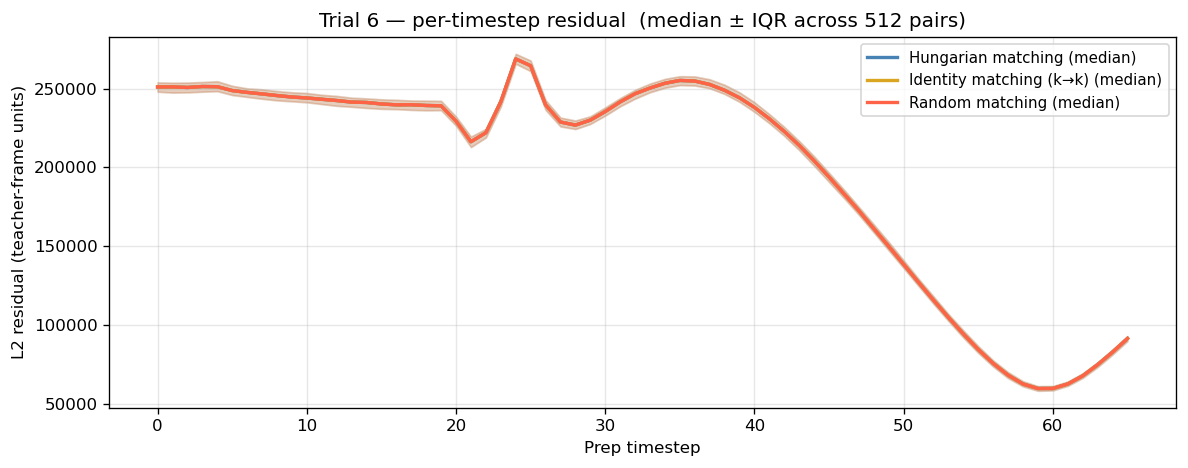

In [90]:
# Per-pair, per-timestep L2 residual in teacher frame  (S, T)
rand_perm   = rng.permutation(S)
diff_match  = X_n - Y_aligned_n                            # Hungarian matched
diff_id     = X_n - Y_natural_aligned                      # identity order
diff_rand   = X_n - Y_natural_aligned[rand_perm]           # random order

resid_match = np.linalg.norm(diff_match, axis=-1)          # (S, T)
resid_id    = np.linalg.norm(diff_id,    axis=-1)
resid_rand  = np.linalg.norm(diff_rand,  axis=-1)

t_axis = np.arange(T)

fig, ax = plt.subplots(figsize=(10, 4))
for resid, color, label in [
    (resid_match, 'steelblue', 'Hungarian matching'),
    (resid_id,    'goldenrod', 'Identity matching (k→k)'),
    (resid_rand,  'tomato',    'Random matching'),
]:
    med = np.median(resid, axis=0)
    p25 = np.percentile(resid, 25, axis=0)
    p75 = np.percentile(resid, 75, axis=0)
    ax.plot(t_axis, med, color=color, label=f'{label} (median)', lw=2)
    ax.fill_between(t_axis, p25, p75, color=color, alpha=0.15)

ax.set_xlabel('Prep timestep')
ax.set_ylabel('L2 residual (teacher-frame units)')
ax.set_title(f'Trial {n} — per-timestep residual  (median ± IQR across {S} pairs)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Best and worst matched pairs

Show individual teacher + matched-student trajectories for the `N_HIGHLIGHT`
pairs with the **lowest** (best) and **highest** (worst) total matching cost.

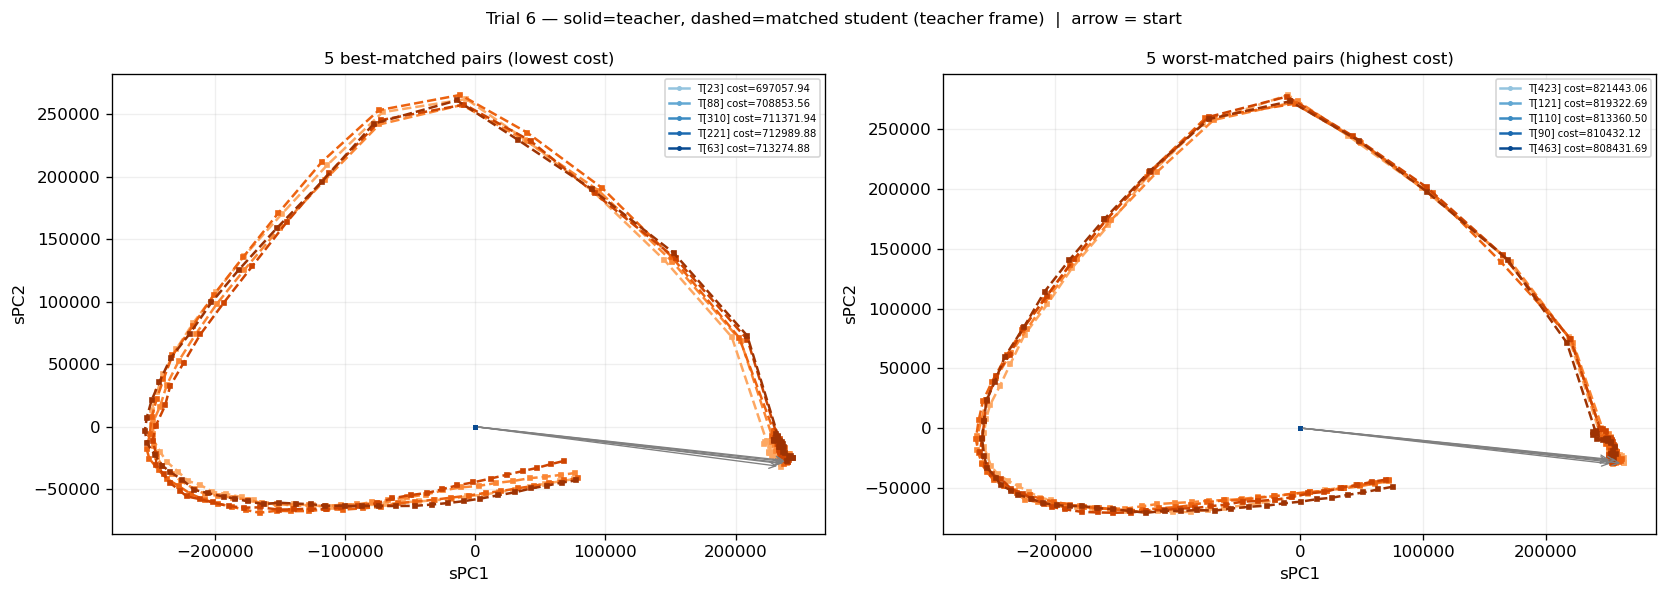

In [91]:
pair_costs  = cost_full[np.arange(S), matches[n]]   # (S,)  original Procrustes cost
best_idx    = np.argsort(pair_costs)[:N_HIGHLIGHT]
worst_idx   = np.argsort(pair_costs)[-N_HIGHLIGHT:][::-1]

def plot_pairs(ax, pair_indices, cmap_teacher='Blues', cmap_student='Oranges'):
    colors_t = plt.get_cmap(cmap_teacher)(np.linspace(0.4, 0.9, len(pair_indices)))
    colors_s = plt.get_cmap(cmap_student)(np.linspace(0.4, 0.9, len(pair_indices)))
    for i, k in enumerate(pair_indices):
        t_pc = spca.transform(X_n[k])           # (T, 3) teacher natural
        s_pc = spca.transform(Y_aligned_n[k])   # (T, 3) matched student in teacher frame
        cost = pair_costs[k]
        ax.plot(t_pc[:, 0], t_pc[:, 1], '-o', ms=2, color=colors_t[i],
                label=f'T[{k}] cost={cost:.2f}')
        ax.plot(s_pc[:, 0], s_pc[:, 1], '--s', ms=2, color=colors_s[i])
        ax.annotate('', xy=(s_pc[0,0], s_pc[0,1]), xytext=(t_pc[0,0], t_pc[0,1]),
                    arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, indices, title in [
    (axes[0], best_idx,  f'{N_HIGHLIGHT} best-matched pairs (lowest cost)'),
    (axes[1], worst_idx, f'{N_HIGHLIGHT} worst-matched pairs (highest cost)'),
]:
    plot_pairs(ax, indices)
    ax.set_xlabel('sPC1'); ax.set_ylabel('sPC2')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=6, loc='best')
    ax.grid(alpha=0.2)

fig.suptitle(f'Trial {n} — solid=teacher, dashed=matched student (teacher frame)  |  arrow = start', fontsize=10)
plt.tight_layout()
plt.show()

## 7. 3-D trajectory cloud (`N_SAMPLES_PLOT` matched pairs)

Teacher samples (blue) and matched student samples rotated into the teacher's
frame (orange).  Overlap means good alignment.  Mean over all 512 samples in black.

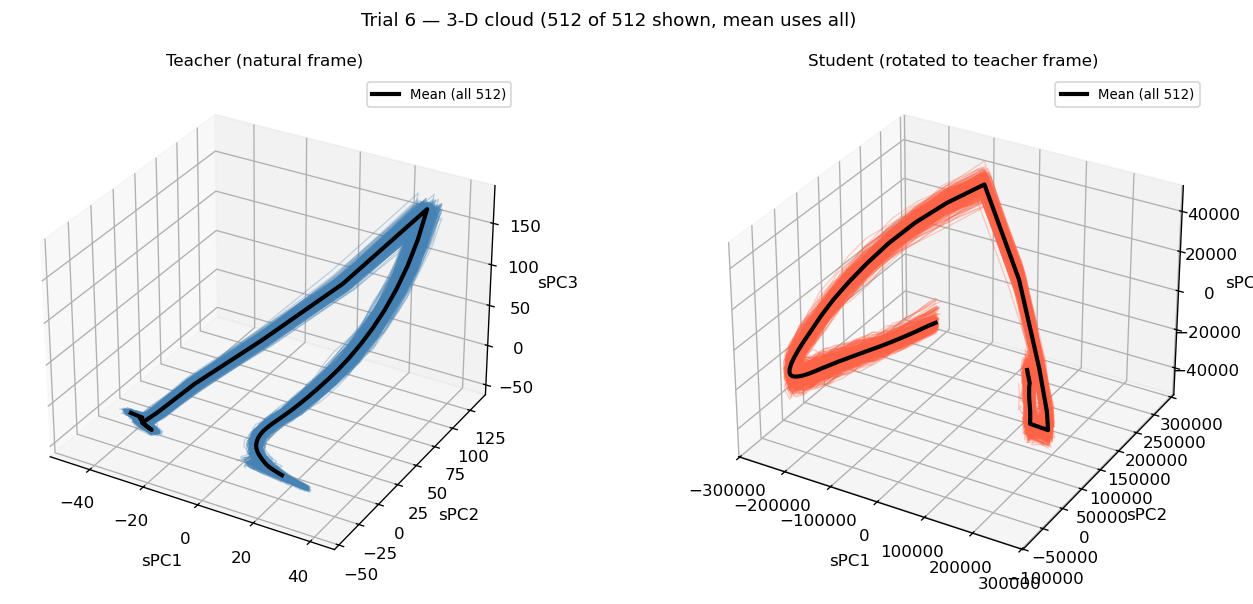

In [92]:
plot_idx = np.arange(N_SAMPLES_PLOT)

fig = plt.figure(figsize=(12, 5))

for col, (traj, full_traj, label, color) in enumerate([
    (X_n[plot_idx],         X_n,          'Teacher (natural frame)',                 'steelblue'),
    (Y_aligned_n[plot_idx], Y_aligned_n,  'Student (rotated to teacher frame)',      'tomato'),
]):
    ax = fig.add_subplot(1, 2, col + 1, projection='3d')
    traj_pc = project_spatial(traj)
    for k in range(N_SAMPLES_PLOT):
        ax.plot(traj_pc[k, :, 0], traj_pc[k, :, 1], traj_pc[k, :, 2],
                color=color, alpha=0.3, lw=0.8)
    full_pc  = project_spatial(full_traj)
    mean_pc  = full_pc.mean(axis=0)
    ax.plot(mean_pc[:, 0], mean_pc[:, 1], mean_pc[:, 2],
            color='black', lw=2.5, label=f'Mean (all {S})', zorder=5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('sPC1'); ax.set_ylabel('sPC2'); ax.set_zlabel('sPC3')
    ax.legend(fontsize=8)

fig.suptitle(f'Trial {n} — 3-D cloud ({N_SAMPLES_PLOT} of {S} shown, mean uses all)', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Mean trajectories (trial `TRIAL_IDX`)

Average over all S=512 matched + aligned samples to get one clean mean trajectory
per model.  Both are shown in teacher-frame sPC space.

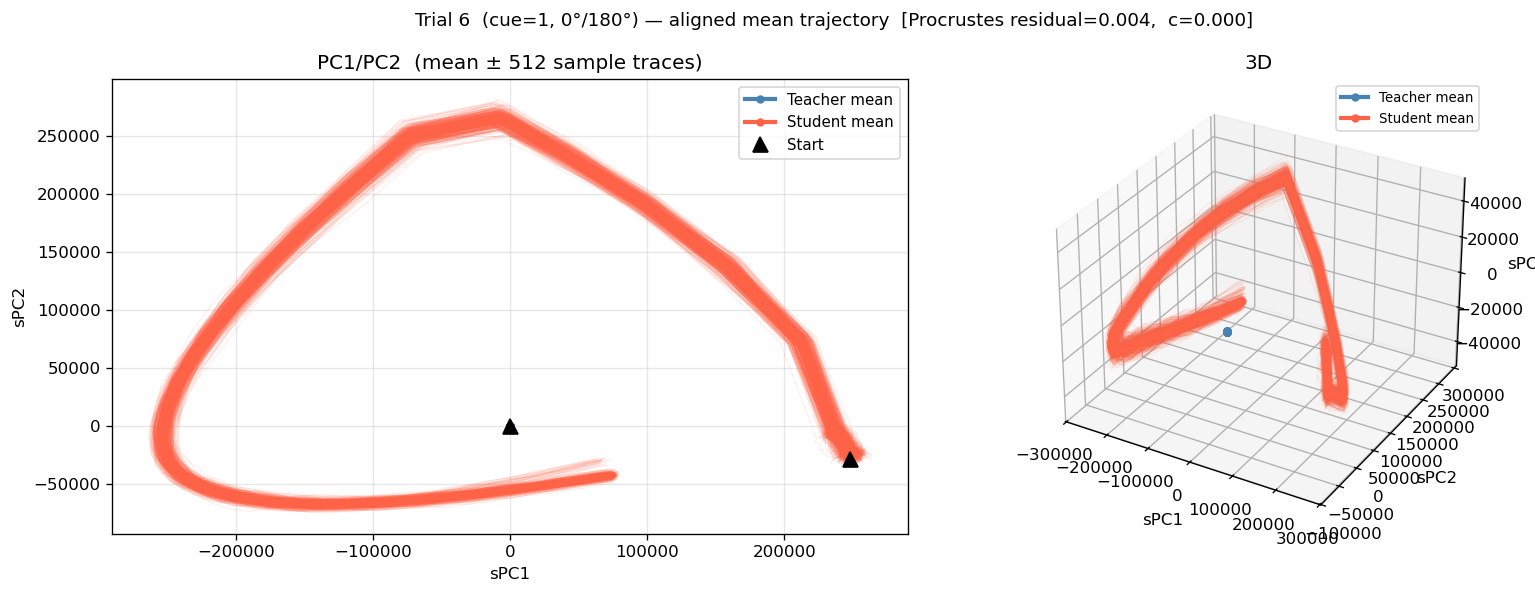

Mean-trajectory RMSE (teacher-frame units): 55989.1029


In [93]:
# Mean trajectories averaged over all S=512 samples for trial TRIAL_IDX.
# Mirrors compare_two_models_prep_trajectories.ipynb style.

X_mean_n = X_n.mean(axis=0)           # (T, M) teacher mean
Y_mean_n = Y_aligned_n.mean(axis=0)   # (T, M) student mean, teacher frame

X_mean_pc = spca.transform(X_mean_n)  # (T, 3)
Y_mean_pc = spca.transform(Y_mean_n)  # (T, 3)

fig = plt.figure(figsize=(14, 5))

# 2D: PC1 / PC2
ax1 = fig.add_subplot(1, 2, 1)
for k in range(N_SAMPLES_PLOT):
    x_s = project_spatial(X_n[[k]])[0, :, :2]
    y_s = project_spatial(Y_aligned_n[[k]])[0, :, :2]
    ax1.plot(x_s[:, 0], x_s[:, 1], color='steelblue', alpha=0.12, lw=0.6)
    ax1.plot(y_s[:, 0], y_s[:, 1], color='tomato',    alpha=0.12, lw=0.6)
ax1.plot(X_mean_pc[:, 0], X_mean_pc[:, 1], '-o', ms=4, color='steelblue', lw=2.5, label='Teacher mean')
ax1.plot(Y_mean_pc[:, 0], Y_mean_pc[:, 1], '-o', ms=4, color='tomato',    lw=2.5, label='Student mean')
ax1.plot(X_mean_pc[0, 0], X_mean_pc[0, 1], 'k^', ms=9, zorder=6, label='Start')
ax1.plot(Y_mean_pc[0, 0], Y_mean_pc[0, 1], 'k^', ms=9, zorder=6)
ax1.set_xlabel('sPC1'); ax1.set_ylabel('sPC2')
ax1.set_title(f'PC1/PC2  (mean ± {N_SAMPLES_PLOT} sample traces)')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for k in range(N_SAMPLES_PLOT):
    x_s = project_spatial(X_n[[k]])[0]
    y_s = project_spatial(Y_aligned_n[[k]])[0]
    ax2.plot(x_s[:, 0], x_s[:, 1], x_s[:, 2], color='steelblue', alpha=0.12, lw=0.6)
    ax2.plot(y_s[:, 0], y_s[:, 1], y_s[:, 2], color='tomato',    alpha=0.12, lw=0.6)
ax2.plot(X_mean_pc[:, 0], X_mean_pc[:, 1], X_mean_pc[:, 2],
         '-o', ms=4, color='steelblue', lw=2.5, label='Teacher mean')
ax2.plot(Y_mean_pc[:, 0], Y_mean_pc[:, 1], Y_mean_pc[:, 2],
         '-o', ms=4, color='tomato',    lw=2.5, label='Student mean')
ax2.set_xlabel('sPC1'); ax2.set_ylabel('sPC2'); ax2.set_zlabel('sPC3')
ax2.set_title('3D')
ax2.legend(fontsize=8)

fig.suptitle(
    f'Trial {n}  (cue=1, 0°/180°) — aligned mean trajectory  '
    f'[Procrustes residual={result.residual:.3f},  c={c:.3f}]',
    fontsize=11,
)
plt.tight_layout()
plt.show()

print(f'Mean-trajectory RMSE (teacher-frame units): {np.sqrt(((X_mean_n - Y_mean_n)**2).mean()):.4f}')

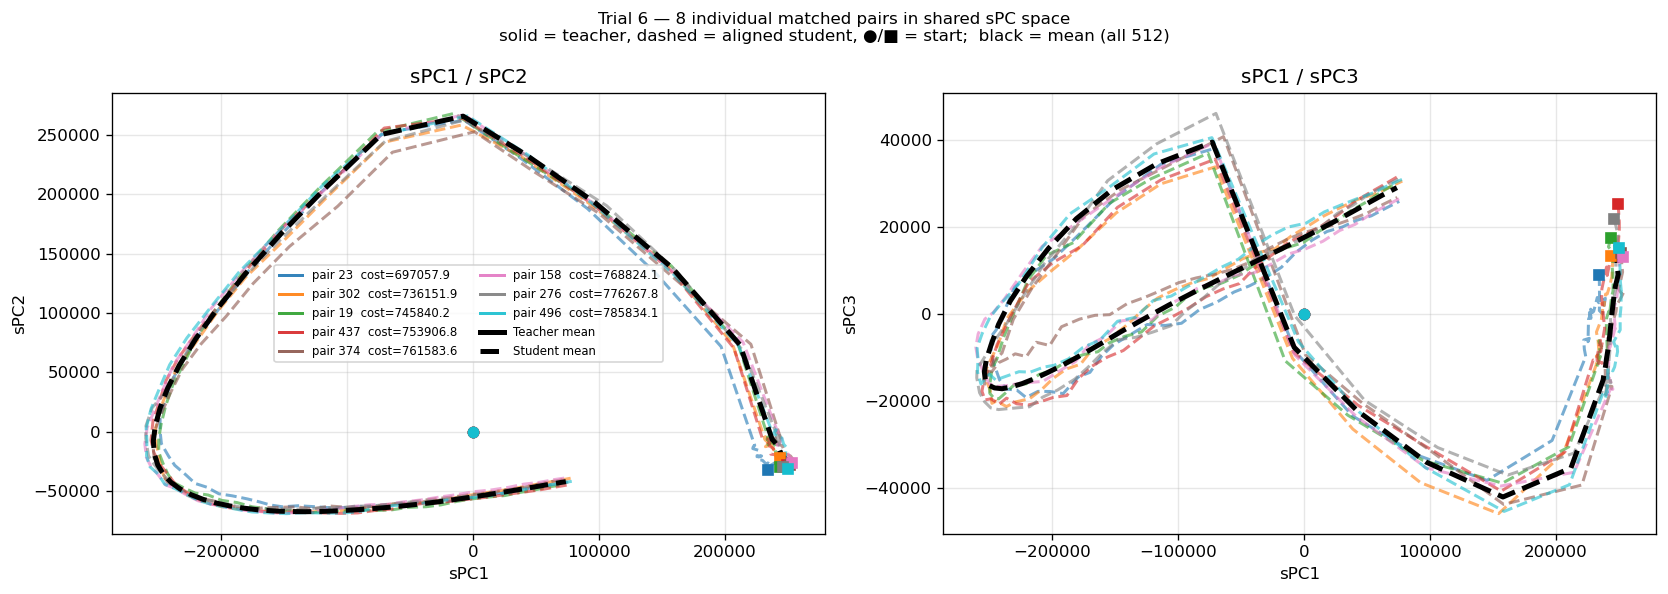

In [94]:
# Show a small number of individual matched pairs in the shared sPC space.
# Each colour is one teacher–student pair; solid = teacher, dashed = aligned student.
# Pairs are chosen to span the full cost range (best → worst).
N_SHOW = 8
pair_order = np.argsort(cost_full[np.arange(S), matches[n]])
step = max(1, S // N_SHOW)
pair_indices = pair_order[::step][:N_SHOW]

colors = plt.cm.tab10(np.linspace(0, 0.9, N_SHOW))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (xi, yi) in zip(axes, [(0, 1), (0, 2)]):
    for i, k in enumerate(pair_indices):
        t_pc = spca.transform(X_n[k])           # (T, 3) teacher
        s_pc = spca.transform(Y_aligned_n[k])   # (T, 3) aligned student
        col  = colors[i]
        match_cost = cost_full[k, matches[n, k]]
        ax.plot(t_pc[:, xi], t_pc[:, yi], '-',  color=col, lw=1.8, alpha=0.9,
                label=f'pair {k}  cost={match_cost:.1f}')
        ax.plot(s_pc[:, xi], s_pc[:, yi], '--', color=col, lw=1.8, alpha=0.6)
        # mark start point
        ax.plot(t_pc[0, xi], t_pc[0, yi], 'o', color=col, ms=6, zorder=5)
        ax.plot(s_pc[0, xi], s_pc[0, yi], 's', color=col, ms=6, zorder=5)
    # mean on top
    ax.plot(X_mean_pc[:, xi], X_mean_pc[:, yi], 'k-',  lw=3, label='Teacher mean')
    ax.plot(Y_mean_pc[:, xi], Y_mean_pc[:, yi], 'k--', lw=3, label='Student mean')
    pc_labels = ['sPC1', 'sPC2', 'sPC3']
    ax.set_xlabel(pc_labels[xi]); ax.set_ylabel(pc_labels[yi])
    ax.grid(alpha=0.3)

axes[0].set_title('sPC1 / sPC2')
axes[1].set_title('sPC1 / sPC3')
axes[0].legend(fontsize=7, loc='best', ncol=2)

fig.suptitle(
    f'Trial {n} — {N_SHOW} individual matched pairs in shared sPC space\n'
    'solid = teacher, dashed = aligned student, ●/■ = start;  '
    'black = mean (all 512)',
    fontsize=10,
)
plt.tight_layout()
plt.show()


## 9. Residual across all trials

Per-timestep residual (median ± IQR) pooled over **all N×S pairs** —
gives a population-level picture of alignment quality.

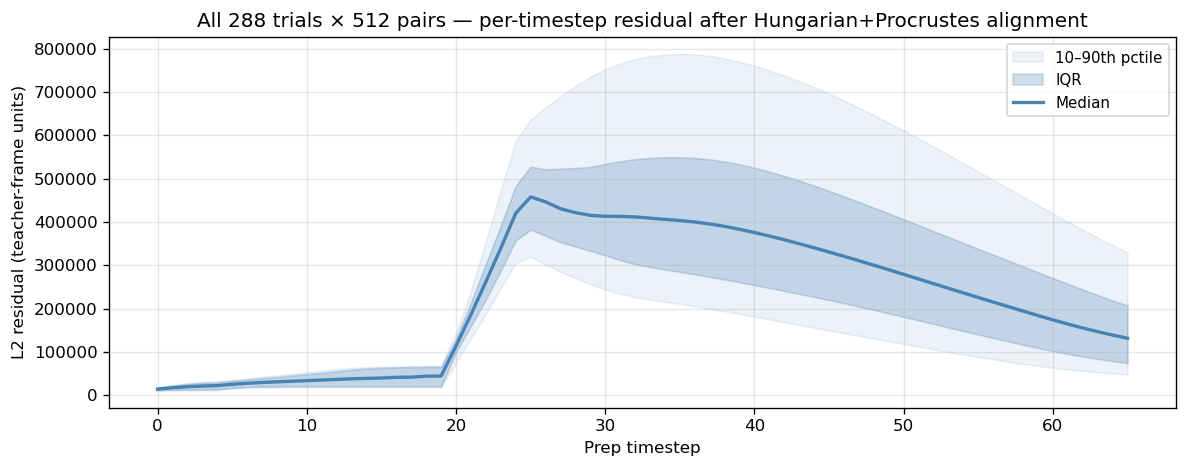

Mean residual (teacher frame): 248423.5542


In [95]:
# Aligned arrays for all trials — student rotated into teacher frame
Y_matched_all  = Y[np.arange(N)[:, None], matches]     # (N, S, T, M)
Y_aligned_all  = (Y_matched_all @ R.T) / c              # (N, S, T, M) student in teacher frame

diff_all  = X - Y_aligned_all                           # (N, S, T, M)
resid_all = np.linalg.norm(diff_all, axis=-1)           # (N, S, T)

resid_pooled = resid_all.reshape(N * S, T)

fig, ax = plt.subplots(figsize=(10, 4))
med = np.median(resid_pooled, axis=0)
p25 = np.percentile(resid_pooled, 25, axis=0)
p75 = np.percentile(resid_pooled, 75, axis=0)
p10 = np.percentile(resid_pooled, 10, axis=0)
p90 = np.percentile(resid_pooled, 90, axis=0)
t_axis = np.arange(T)
ax.fill_between(t_axis, p10, p90, color='steelblue', alpha=0.10, label='10–90th pctile')
ax.fill_between(t_axis, p25, p75, color='steelblue', alpha=0.25, label='IQR')
ax.plot(t_axis, med, color='steelblue', lw=2, label='Median')
ax.set_xlabel('Prep timestep')
ax.set_ylabel('L2 residual (teacher-frame units)')
ax.set_title(f'All {N} trials × {S} pairs — per-timestep residual after Hungarian+Procrustes alignment')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean residual (teacher frame): {resid_pooled.mean():.4f}')

## 10. Per-trial Procrustes distance

Average over S=512 samples per trial to get a clean per-trial mean trajectory,
then measure the normalised Frobenius distance in the globally-fitted teacher frame.
Trials with large bimodal sample clouds (swap conditions) may show higher distances.

Per-trial Procrustes distance:  mean=1097.6474  median=949.2742  std=576.8256
Global individual-sample residual (§1): 0.0041
Worst trial: 105  dist=2949.7024
Best  trial: 37  dist=9.5845


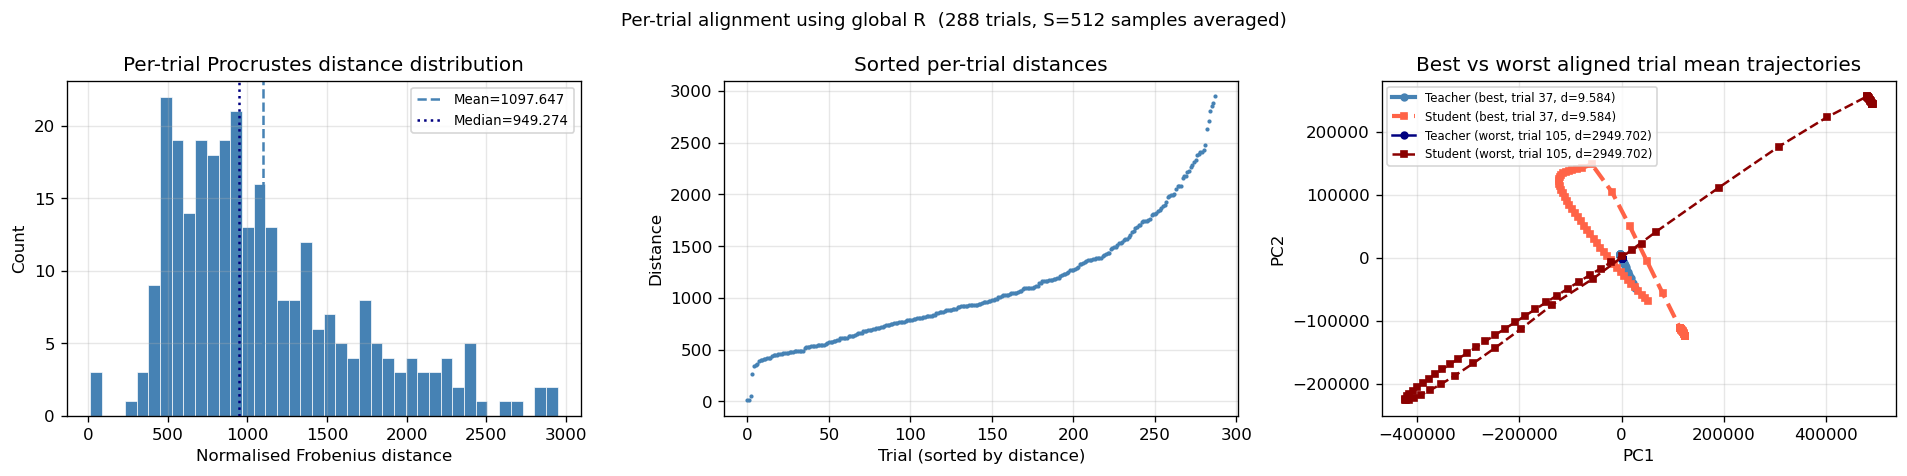

In [96]:
# Per-trial mean trajectories (average over S=512 samples, keep N=288 trials)
X_trial = X_c.mean(axis=1)   # (N, T, M)
Y_trial = Y_c.mean(axis=1)   # (N, T, M)

# Apply the globally-fitted rotation and scale (no per-trial re-fitting)
Y_trial_aligned = (Y_trial @ R.T) / c   # (N, T, M) — student in teacher frame

# Per-trial normalised Frobenius distance
diff_trial  = X_trial - Y_trial_aligned          # (N, T, M)
num         = np.linalg.norm(diff_trial.reshape(N, -1), axis=1)   # (N,)
denom       = np.linalg.norm(X_trial.reshape(N, -1),   axis=1)    # (N,)
dist_trial  = num / (denom + 1e-12)              # (N,)

print(f'Per-trial Procrustes distance:  mean={dist_trial.mean():.4f}  '
      f'median={np.median(dist_trial):.4f}  std={dist_trial.std():.4f}')
print(f'Global individual-sample residual (§1): {result.residual:.4f}')
print(f'Worst trial: {dist_trial.argmax()}  dist={dist_trial.max():.4f}')
print(f'Best  trial: {dist_trial.argmin()}  dist={dist_trial.min():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: distribution of per-trial distances
ax = axes[0]
ax.hist(dist_trial, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(dist_trial.mean(),   color='steelblue', ls='--', lw=1.5, label=f'Mean={dist_trial.mean():.3f}')
ax.axvline(np.median(dist_trial), color='navy',   ls=':',  lw=1.5, label=f'Median={np.median(dist_trial):.3f}')
ax.set_xlabel('Normalised Frobenius distance'); ax.set_ylabel('Count')
ax.set_title('Per-trial Procrustes distance distribution')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Middle: distance vs trial index (sorted to reveal structure)
ax2 = axes[1]
order = np.argsort(dist_trial)
ax2.plot(dist_trial[order], '.', color='steelblue', ms=3)
ax2.set_xlabel('Trial (sorted by distance)'); ax2.set_ylabel('Distance')
ax2.set_title('Sorted per-trial distances')
ax2.grid(alpha=0.3)

# Right: best and worst trial mean trajectories in PCA space
pca_t = PCA(n_components=2)
pca_t.fit(np.vstack([X_trial.reshape(-1, M), Y_trial_aligned.reshape(-1, M)]))

ax3 = axes[2]
for trial_idx, color_t, color_s, lw, label_suffix in [
    (dist_trial.argmin(), 'steelblue', 'tomato',     2.5, f' (best, trial {dist_trial.argmin()}, d={dist_trial.min():.3f})'),
    (dist_trial.argmax(), 'navy',      'darkred',    1.5, f' (worst, trial {dist_trial.argmax()}, d={dist_trial.max():.3f})'),
]:
    xt = pca_t.transform(X_trial[trial_idx])
    yt = pca_t.transform(Y_trial_aligned[trial_idx])
    ax3.plot(xt[:, 0], xt[:, 1], '-o', ms=4, color=color_t, lw=lw, label=f'Teacher{label_suffix}')
    ax3.plot(yt[:, 0], yt[:, 1], '--s', ms=4, color=color_s, lw=lw, label=f'Student{label_suffix}')
ax3.set_xlabel('PC1'); ax3.set_ylabel('PC2')
ax3.set_title('Best vs worst aligned trial mean trajectories')
ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

fig.suptitle(f'Per-trial alignment using global R  ({N} trials, S={S} samples averaged)', fontsize=11)
plt.tight_layout()
plt.show()

## 11. Final-timestep bimodal split (trial `TRIAL_IDX`)

Sample cloud at the last prep timestep in 16-D (full hidden state, including
the readout subspace).  The swap bimodality — correct vs swapped colour modes —
lives in the readout dimensions and is **only visible in 16-D**, not in the
14-D nullspace projection used in earlier work.

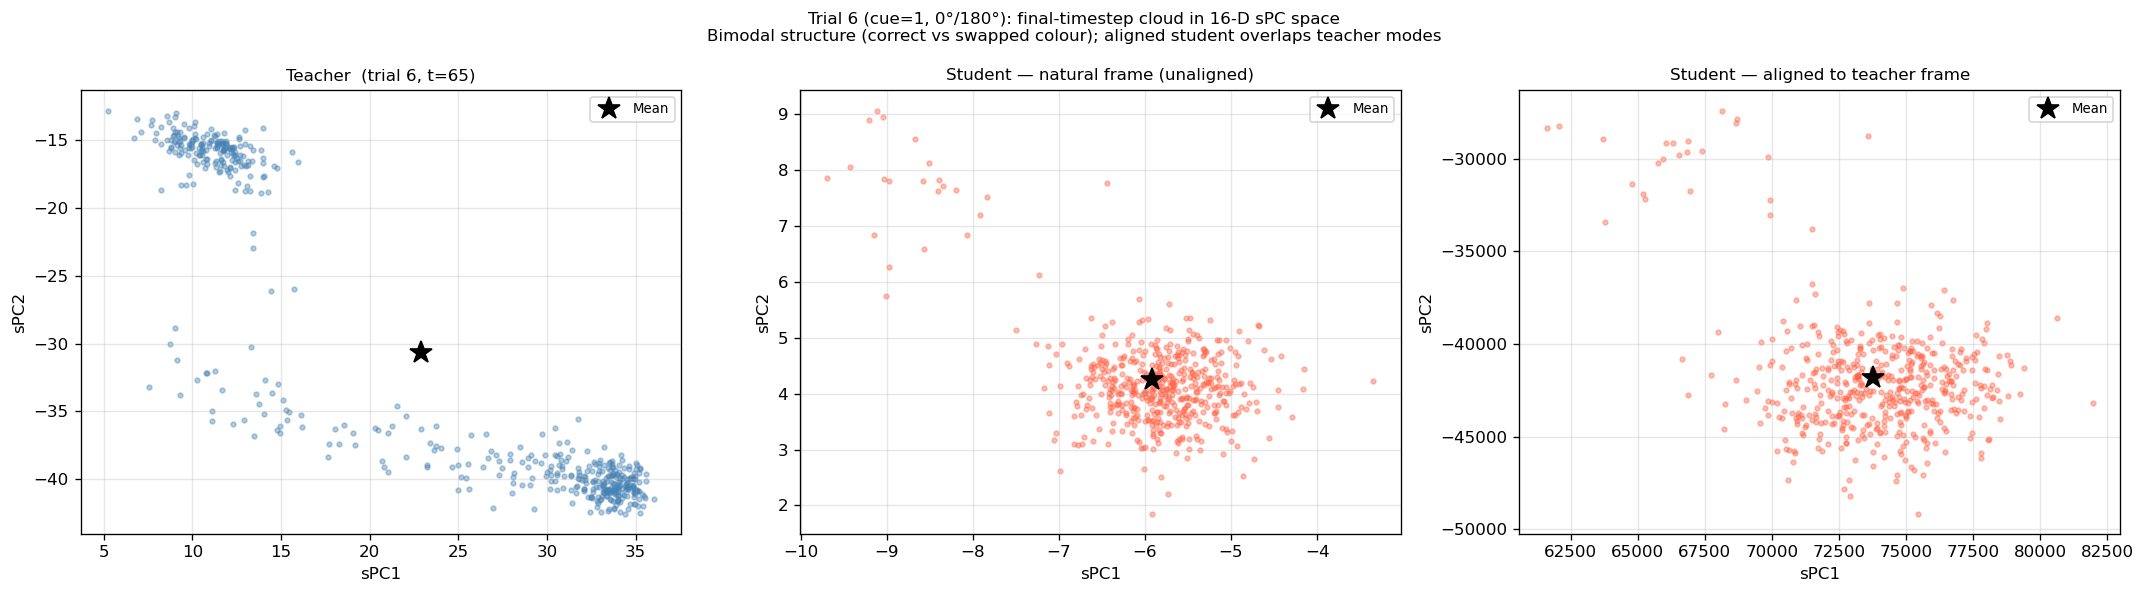

In [97]:
# Three-panel: teacher | student unaligned | student aligned to teacher frame.
# The bimodal structure (correct vs swapped colour) is visible in 16-D because
# the readout subspace is retained.
final_t = T - 1

X_f      = spca.transform(X_n[:, final_t, :])         # (S, 3) teacher
Y_f_raw  = spca.transform(Y_n[:, final_t, :])         # (S, 3) student, natural frame
Y_f_aln  = spca.transform(Y_aligned_n[:, final_t, :]) # (S, 3) student, aligned

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pc, color, title in [
    (axes[0], X_f,     'steelblue', f'Teacher  (trial {n}, t={final_t})'),
    (axes[1], Y_f_raw, 'tomato',    'Student — natural frame (unaligned)'),
    (axes[2], Y_f_aln, 'tomato',    'Student — aligned to teacher frame'),
]:
    ax.scatter(pc[:, 0], pc[:, 1], s=8, alpha=0.4, color=color)
    ax.plot(pc.mean(0)[0], pc.mean(0)[1], 'k*', ms=14, zorder=5, label='Mean')
    ax.set_xlabel('sPC1'); ax.set_ylabel('sPC2')
    ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(
    f'Trial {n} (cue=1, 0°/180°): final-timestep cloud in 16-D sPC space\n'
    'Bimodal structure (correct vs swapped colour); aligned student overlaps teacher modes',
    fontsize=10,
)
plt.tight_layout()
plt.show()


## 12. Ablated direction and global mean alignment

**Ablated direction**: project per-trial mean trajectories onto `nullspace[0]`.
Teacher should be ≈0 (the direction was ablated); student is free to use it.

**Global mean** (baseline only): averaging over all N×S trajectories cancels the
per-trial signal, so the alignment distance here is misleadingly low.

Global-mean Procrustes distance (allow_scaling=True):  0.4946
Individual-sample residual (from §1):                  0.0041

NOTE: global mean hides per-trial signal — see per-trial mean below.


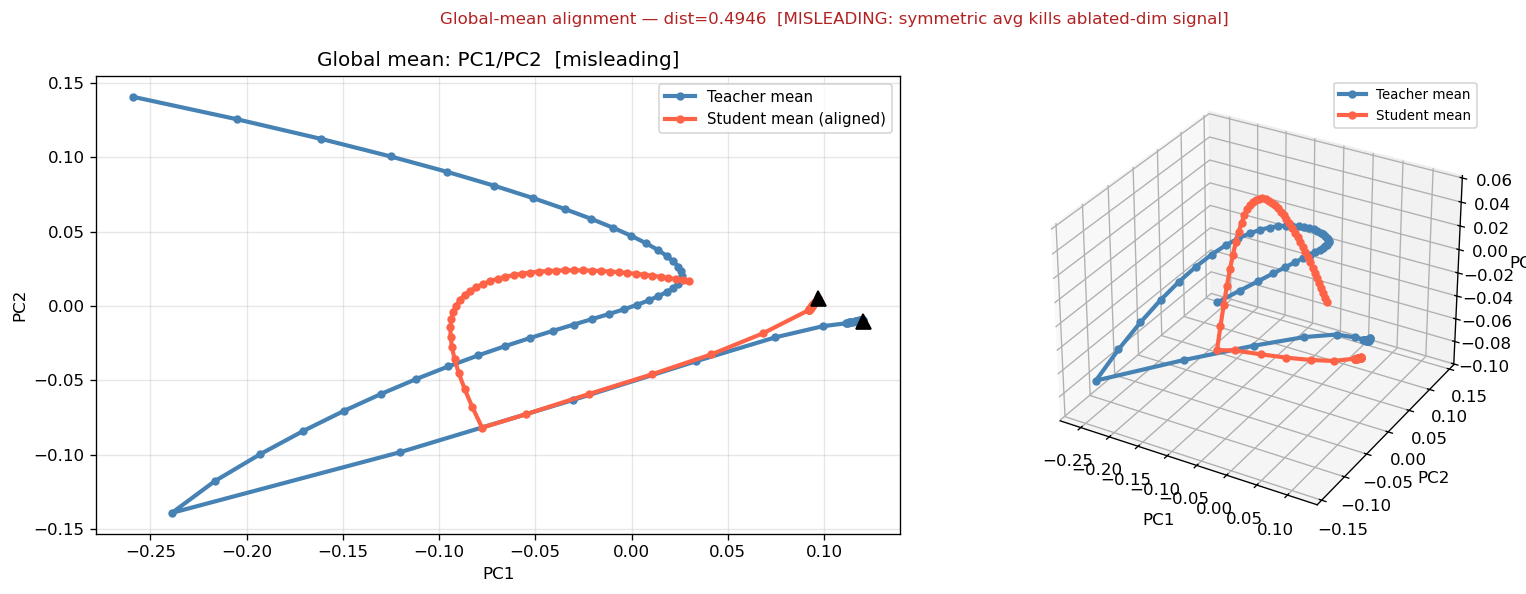


Per-trial PCA explained: ['97.9%', '0.9%', '0.5%']

Nullspace direction 0  across 288 trial means:
  Teacher  grand_mean=-0.0000  std=419.2930
           per-timestep mean range: [-221.232, 101.554]
  Student  grand_mean=0.0000  std=25.9178
           per-timestep mean range: [-30.151, 30.897]


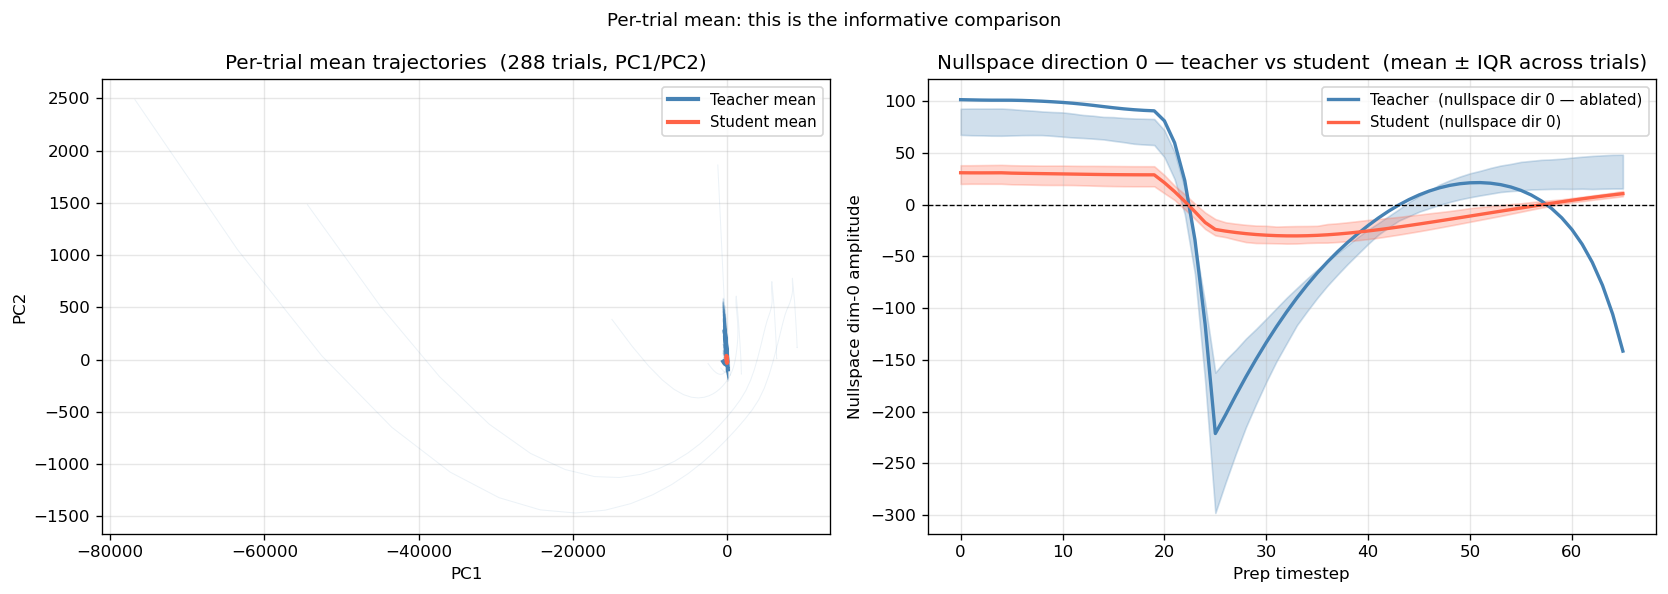

In [98]:
from ddpm.analysis.new_analysis.run_ablation_student_comparison import (
    preprocess_average_trajectories, procrustes_distance,
)

# ── Global mean (all N×S averaged) ───────────────────────────────────────────
# WARNING: this averages over all 288 conditions.  The ablated direction (nullspace
# dim 0) is zero in the teacher by construction; in the student it varies per trial
# (+1 on some conditions, −1 on others) but its mean is ≈0 due to a symmetric trial
# distribution.  The global mean therefore hides exactly the signal we care about.
# The low distance here is expected and uninformative.
avg_X = X_c.mean(axis=(0, 1))   # (T, M)
avg_Y = Y_c.mean(axis=(0, 1))   # (T, M)

X_proc, Y_proc, _ = preprocess_average_trajectories(avg_X, avg_Y, use_zscore=False, pca_dims=6)
mean_proc = procrustes_distance(X_proc, Y_proc, allow_scaling=True)
print(f'Global-mean Procrustes distance (allow_scaling=True):  {mean_proc["distance"]:.4f}')
print(f'Individual-sample residual (from §1):                  {result.residual:.4f}')
print()
print('NOTE: global mean hides per-trial signal — see per-trial mean below.')

X_al = mean_proc['aligned_ref']
Y_al = mean_proc['aligned_cmp']
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(X_al[:, 0], X_al[:, 1], '-o', ms=4, color='steelblue', lw=2.5, label='Teacher mean')
ax1.plot(Y_al[:, 0], Y_al[:, 1], '-o', ms=4, color='tomato',    lw=2.5, label='Student mean (aligned)')
ax1.plot(X_al[0, 0], X_al[0, 1], 'k^', ms=9, zorder=6); ax1.plot(Y_al[0, 0], Y_al[0, 1], 'k^', ms=9, zorder=6)
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.set_title('Global mean: PC1/PC2  [misleading]')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(X_al[:, 0], X_al[:, 1], X_al[:, 2], '-o', ms=4, color='steelblue', lw=2.5, label='Teacher mean')
ax2.plot(Y_al[:, 0], Y_al[:, 1], Y_al[:, 2], '-o', ms=4, color='tomato', lw=2.5, label='Student mean')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3'); ax2.legend(fontsize=8)
fig.suptitle(f'Global-mean alignment — dist={mean_proc["distance"]:.4f}  [MISLEADING: symmetric avg kills ablated-dim signal]',
             fontsize=10, color='firebrick')
plt.tight_layout(); plt.show()

# ── Per-trial mean (N=288 kept, S averaged out) ───────────────────────────────
# Average over samples only → one clean trajectory per condition.
# This preserves per-condition variance, including the ablated direction.
X_trial = X_c.mean(axis=1)   # (N, T, M)
Y_trial = Y_c.mean(axis=1)   # (N, T, M)

# Fit joint PCA on the per-trial means
pca_trial = PCA(n_components=3)
pca_trial.fit(np.vstack([X_trial.reshape(-1, M), Y_trial.reshape(-1, M)]))
print(f'\nPer-trial PCA explained: {[f"{v*100:.1f}%" for v in pca_trial.explained_variance_ratio_]}')

# Project per-trial mean trajectories onto nullspace[0] (direction 0).
# For ablated teacher (TEACHER_DIRECTION_IDX=0): per-timestep mean should be ≈0.
# For unablated teacher (TEACHER_DIRECTION_IDX=None): teacher uses this direction freely.
# grand_mean ≈ 0 in both cases (symmetric trial distribution averages out);
# the per-timestep mean (plotted below) is the informative quantity.
abl_X = X_trial[:, :, 0]   # (N, T)  teacher projected onto nullspace dir 0
abl_Y = Y_trial[:, :, 0]   # (N, T)
print(f'\nNullspace direction 0  across {N} trial means:')
print(f'  Teacher  grand_mean={abl_X.mean():.4f}  std={abl_X.std():.4f}')
print(f'           per-timestep mean range: [{abl_X.mean(0).min():.3f}, {abl_X.mean(0).max():.3f}]')
print(f'  Student  grand_mean={abl_Y.mean():.4f}  std={abl_Y.std():.4f}')
print(f'           per-timestep mean range: [{abl_Y.mean(0).min():.3f}, {abl_Y.mean(0).max():.3f}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all N per-trial trajectories in PCA space
ax = axes[0]
Xp = pca_trial.transform(X_trial.reshape(-1, M)).reshape(N, T, 3)
Yp = pca_trial.transform(Y_trial.reshape(-1, M)).reshape(N, T, 3)
for k in range(N):
    ax.plot(Xp[k, :, 0], Xp[k, :, 1], color='steelblue', alpha=0.10, lw=0.6)
    ax.plot(Yp[k, :, 0], Yp[k, :, 1], color='tomato',    alpha=0.10, lw=0.6)
ax.plot(Xp.mean(0)[:, 0], Xp.mean(0)[:, 1], color='steelblue', lw=2.5, label='Teacher mean')
ax.plot(Yp.mean(0)[:, 0], Yp.mean(0)[:, 1], color='tomato',    lw=2.5, label='Student mean')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Per-trial mean trajectories  ({N} trials, PC1/PC2)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Right: ablated dimension directly over time
ax2 = axes[1]
t_axis = np.arange(T)
for data, color, label in [
    (X_trial[:, :, 0], 'steelblue', f'Teacher  (nullspace dir 0{" — ablated" if TEACHER_DIRECTION_IDX is not None else ""})'),
    (Y_trial[:, :, 0], 'tomato',    f'Student  (nullspace dir 0)'),
]:
    d = data if data.ndim == 2 else data
    ax2.fill_between(t_axis,
        np.percentile(d, 25, axis=0), np.percentile(d, 75, axis=0),
        color=color, alpha=0.25)
    ax2.plot(t_axis, d.mean(0), color=color, lw=2, label=label)
ax2.axhline(0, color='k', ls='--', lw=0.8)
ax2.set_xlabel('Prep timestep'); ax2.set_ylabel('Nullspace dim-0 amplitude')
ax2.set_title('Nullspace direction 0 — teacher vs student  (mean ± IQR across trials)')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

fig.suptitle('Per-trial mean: this is the informative comparison', fontsize=11)
plt.tight_layout()
plt.show()